# Entrenamiento y Optimización — Smoking Dataset

Pipeline de modelado: baseline, optimización de hiperparámetros y evaluación final.
Modelos: Regresión Logística, Random Forest, XGBoost.
Métrica principal: **F1-score**.

## Librerias

In [175]:
!pip install seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [176]:
!pip install xgboost


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Admin\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [177]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix,
    precision_score, recall_score, ConfusionMatrixDisplay,
    RocCurveDisplay
)
%matplotlib inline
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["font.size"] = 12
sns.set_theme(style="whitegrid")

PAL = {0: "#378ADD", 1: "#D85A30"}
SEED = 42

## 1. Carga del dataset procesado y split train/test

In [178]:
import os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_DIR, "data", "processed", "smoking_processed.csv")


In [179]:

df = pd.read_csv(DATA_PATH)
df["smoking"] = df["smoking"].astype(int)
print(f"Shape: {df.shape}")
df.head(10)

Shape: (49866, 15)


,gender,age,waist_cm,systolic,relaxation,triglyceride,hdl,hemoglobin,serum_creatinine,gtp,dental_caries,smoking,liver_score,lipid_ratio,gender_x_hemoglobin
0,0,-0.347134,3.38,4.75,3.04,3.42,3.04,0.51,0.00,1.13,0,0,2.67,1.125000,0.00
1,0,-0.347134,3.38,4.96,2.92,4.79,1.75,0.50,0.00,0.75,0,0,2.46,2.737143,0.00
2,1,0.893385,3.33,5.75,3.58,7.58,2.29,0.63,0.04,0.92,0,1,2.47,3.310044,0.63
3,1,-0.347134,3.67,4.17,2.50,10.58,1.88,0.59,0.04,0.75,0,0,2.62,5.627660,0.59
4,0,-0.347134,3.58,5.00,3.08,3.08,2.58,0.50,0.00,0.92,0,0,2.17,1.193798,0.00
5,1,-1.174147,3.54,5.33,3.17,8.29,2.00,0.67,0.04,1.38,0,0,3.26,4.145000,0.67
6,1,-0.347134,3.55,4.83,3.42,2.83,2.29,0.71,0.00,1.63,1,1,3.64,1.235808,0.71
7,1,0.066372,4.00,6.38,4.00,11.21,1.42,0.63,0.04,4.63,0,0,9.17,7.894366,0.63
8,0,0.479878,3.54,4.79,3.08,2.75,2.00,0.55,0.01,0.58,0,0,3.16,1.375000,0.00
9,1,0.066372,3.71,4.71,2.67,6.13,1.79,0.67,0.01,2.63,0,0,4.71,3.424581,0.67


In [180]:
X= df.drop(columns=['smoking'])

y = df["smoking"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Balance train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"Balance test:\n{y_test.value_counts(normalize=True).round(3)}")


Train: (39892, 14)  |  Test: (9974, 14)
Balance train:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64
Balance test:
smoking
0    0.634
1    0.366
Name: proportion, dtype: float64


## Funciones auxiliares

In [181]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]
    return {
        "Modelo": nombre,
        "F1_fumador": round(f1_score(y_te, y_pred, pos_label=1), 4),  # métrica objetivo
        "ROC-AUC": round(roc_auc_score(y_te, y_prob), 4),
        "Accuracy": round(accuracy_score(y_te, y_pred), 4),
        "Precision_fumador": round(precision_score(y_te, y_pred, pos_label=1), 4),
        "Recall_fumador": round(recall_score(y_te, y_pred, pos_label=1), 4),
        "_modelo": modelo,
        "_y_pred": y_pred,
        "_y_prob": y_prob
    }

def mostrar_confusion(resultados, y_te):
    fig, axes = plt.subplots(1, len(resultados), figsize=(5 * len(resultados), 4))
    for ax, r in zip(axes, resultados):
        cm = confusion_matrix(y_te, r["_y_pred"])
        ConfusionMatrixDisplay(cm, display_labels=["No fuma", "Fuma"]).plot(ax=ax, colorbar=False)
        ax.set_title(r["Modelo"])
    plt.tight_layout()
    plt.show()

def mostrar_roc(resultados, y_te):
    fig, ax = plt.subplots(figsize=(7, 5))
    for r in resultados:
        RocCurveDisplay.from_predictions(y_te, r["_y_prob"], name=r["Modelo"], ax=ax)
    ax.set_title("Curvas ROC — comparación de modelos")
    plt.tight_layout()
    plt.show()

## 3. Parámetros por defecto

Entrenamos los 3 modelos sin optimización para tener una referencia inicial.
Usamos `class_weight="balanced"` en LR y RF para compensar el desbalance (63/37).

In [182]:
modelos_base = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ("Random Forest",       RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED)),
    ("XGBoost",             XGBClassifier(n_estimators=100, 
                                          scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                          random_state=SEED, eval_metric="logloss", verbosity=0)),
]

In [183]:
resultados_base = []

for nombre, modelo in modelos_base:
    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados_base.append(r)


In [184]:
df_base = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base])
df_base.set_index("Modelo")


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
Logistic Regression,0.7035,0.8263,0.7110,0.5631,0.9372
Random Forest,0.7167,0.8788,0.7917,0.7129,0.7207
XGBoost,0.7139,0.8443,0.7521,0.6176,0.8457


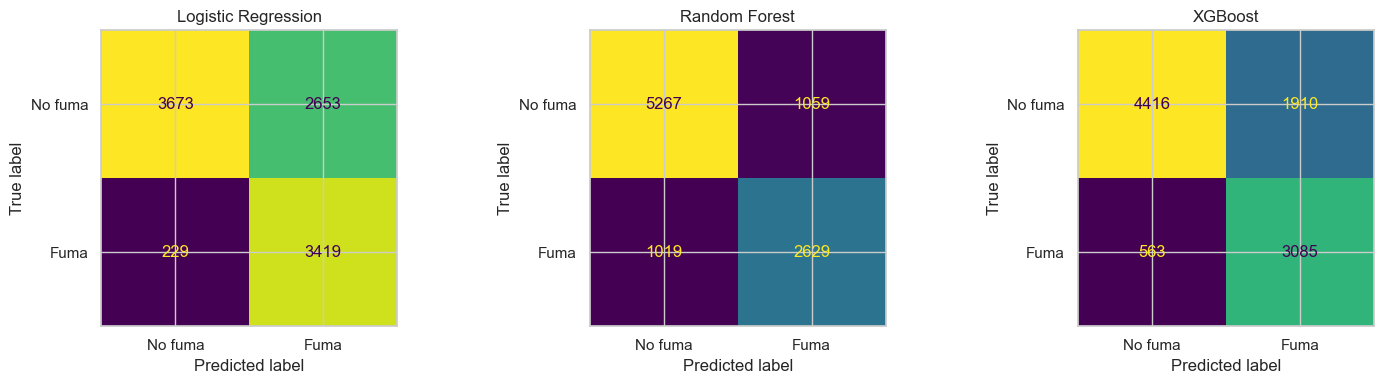

In [185]:
mostrar_confusion(resultados_base, y_test)


### sin balance

In [186]:
modelos_base = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=SEED)),
    ("Random Forest",       RandomForestClassifier(n_estimators=300, random_state=SEED)),
    ("XGBoost",             XGBClassifier(n_estimators=100, 
                                          scale_pos_weight=y_train.value_counts()[0]/y_train.value_counts()[1],
                                          random_state=SEED, eval_metric="logloss", verbosity=0)),
]

In [187]:
resultados_base = []

for nombre, modelo in modelos_base:
    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados_base.append(r)


In [188]:
df_base = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base])
df_base.set_index("Modelo")


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
Logistic Regression,0.6690,0.8259,0.7452,0.6374,0.7039
Random Forest,0.7228,0.8792,0.7916,0.7036,0.7431
XGBoost,0.7139,0.8443,0.7521,0.6176,0.8457


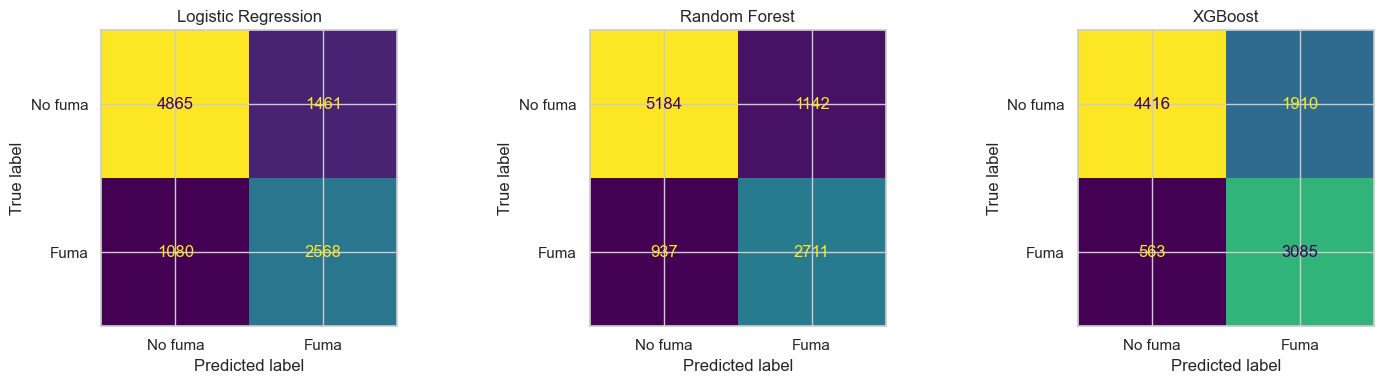

In [189]:
mostrar_confusion(resultados_base, y_test)


### 4. Optimización de hiperparámetros (RandomizedSearchCV)

Buscamos los mejores hiperparámetros para cada modelo usando validación cruzada estratificada (5 folds).
Métrica de optimización: **F1-score** sobre la clase positiva (fumador).

In [190]:
from scipy.stats import randint, uniform

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
#logistic regression
param_lr = {
    "C": uniform(0.01, 10),
    "solver": ["lbfgs", "saga"],
    "max_iter": [500, 1000, 2000],
}
search_lr = RandomizedSearchCV(
    LogisticRegression(class_weight="balanced", random_state=SEED),
    param_lr, n_iter=20, scoring="f1", cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
search_lr.fit(X_train, y_train)
print("LR best params:", search_lr.best_params_)
print(f"LR best CV F1: {search_lr.best_score_:.4f}")


LR best params: {'C': np.float64(0.017787658410143285), 'max_iter': 500, 'solver': 'lbfgs'}
LR best CV F1: 0.7032


In [191]:
#  Random Forest 
param_rf = {
    "n_estimators": randint(100, 500),
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_leaf": randint(1, 10),
    "max_features": ["sqrt", "log2"],
}
search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=SEED),
    param_rf, n_iter=30, scoring="f1", cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
search_rf.fit(X_train, y_train)
print("RF best params:", search_rf.best_params_)
print(f"RF best CV F1: {search_rf.best_score_:.4f}")


RF best params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'n_estimators': 314}
RF best CV F1: 0.7275


In [192]:
# xgboost
scale_pw = y_train.value_counts()[0] / y_train.value_counts()[1]
param_xgb = {
    "n_estimators": randint(100, 400),
    "max_depth": randint(3, 10),
    "learning_rate": uniform(0.01, 0.3),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2),
}
search_xgb = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pw, random_state=SEED,
                  eval_metric="logloss", verbosity=0),
    param_xgb, n_iter=30, scoring="f1", cv=cv,
    random_state=SEED, n_jobs=-1, verbose=0
)
search_xgb.fit(X_train, y_train)
print("XGB best params:", search_xgb.best_params_)
print(f"XGB best CV F1: {search_xgb.best_score_:.4f}")

XGB best params: {'colsample_bytree': np.float64(0.6479461469334731), 'learning_rate': np.float64(0.11128455142108838), 'max_depth': 9, 'n_estimators': 259, 'reg_alpha': np.float64(0.5187906217433661), 'reg_lambda': np.float64(1.9060379177903557), 'subsample': np.float64(0.7454518409517176)}
XGB best CV F1: 0.7184


## 5. Evaluación de modelos optimizados

In [193]:
modelos_opt = [
    ("LR Optimizado",  search_lr.best_estimator_),
    ("RF Optimizado",  search_rf.best_estimator_),
    ("XGB Optimizado", search_xgb.best_estimator_),
]

resultados_opt = []
for nombre, modelo in modelos_opt:
    r = evaluar(nombre, modelo, X_train, y_train, X_test, y_test)
    resultados_opt.append(r)

df_opt = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_opt])
df_opt.set_index("Modelo")


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
LR Optimizado,0.7023,0.8247,0.7089,0.5610,0.9386
RF Optimizado,0.7298,0.8699,0.7802,0.6631,0.8114
XGB Optimizado,0.7201,0.8559,0.7736,0.6572,0.7963


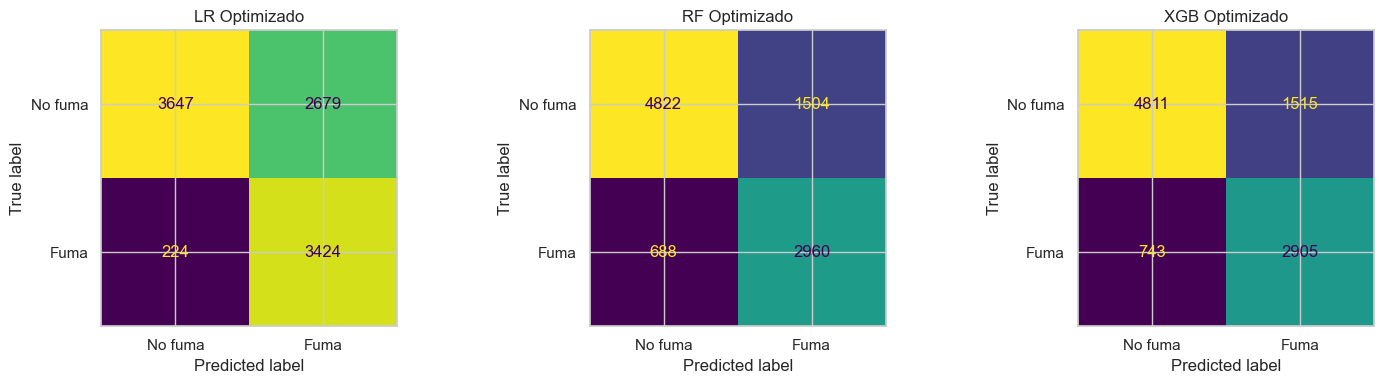

In [194]:
mostrar_confusion(resultados_opt, y_test)


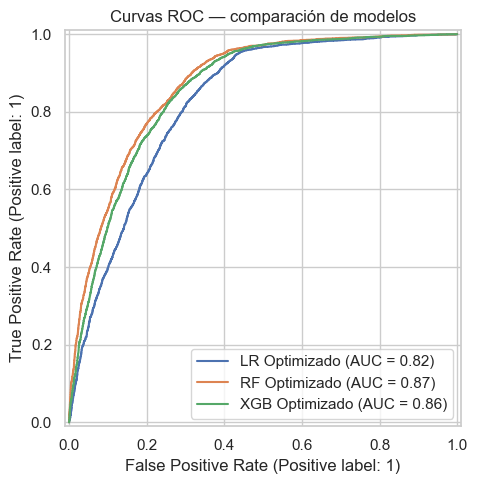

In [195]:
mostrar_roc(resultados_opt, y_test)


## 6. Comparación baseline vs. optimizado

In [196]:
# Reentrenar baselines con class_weight='balanced' para comparación justa
modelos_base_cw = [
    ("LR Baseline",  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ("RF Baseline",  RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=SEED)),
    ("XGB Baseline", XGBClassifier(n_estimators=100, scale_pos_weight=scale_pw,
                                   random_state=SEED, eval_metric="logloss", verbosity=0)),
]
resultados_base_cw = [evaluar(n, m, X_train, y_train, X_test, y_test) for n, m in modelos_base_cw]

df_comp = pd.concat([
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_base_cw]),
    pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")} for r in resultados_opt]),
]).set_index("Modelo")

print(df_comp.to_string())
df_comp


                F1_fumador  ROC-AUC  Accuracy  Precision_fumador  Recall_fumador
Modelo                                                                          
LR Baseline         0.7035   0.8263    0.7110             0.5631          0.9372
RF Baseline         0.7167   0.8788    0.7917             0.7129          0.7207
XGB Baseline        0.7139   0.8443    0.7521             0.6176          0.8457
LR Optimizado       0.7023   0.8247    0.7089             0.5610          0.9386
RF Optimizado       0.7298   0.8699    0.7802             0.6631          0.8114
XGB Optimizado      0.7201   0.8559    0.7736             0.6572          0.7963


,F1_fumador,ROC-AUC,Accuracy,Precision_fumador,Recall_fumador
Modelo,,,,,
LR Baseline,0.7035,0.8263,0.7110,0.5631,0.9372
RF Baseline,0.7167,0.8788,0.7917,0.7129,0.7207
XGB Baseline,0.7139,0.8443,0.7521,0.6176,0.8457
LR Optimizado,0.7023,0.8247,0.7089,0.5610,0.9386
RF Optimizado,0.7298,0.8699,0.7802,0.6631,0.8114
XGB Optimizado,0.7201,0.8559,0.7736,0.6572,0.7963


Modelo seleccionado: Random Forest Optimizado

Con un F1-score de 0.730, ROC-AUC de 0.870 y Accuracy de 0.780, Random Forest Optimizado obtuvo el mejor balance entre precisión y recall (0.663 y 0.811 respectivamente). Si bien la Regresión Logística alcanzó un recall más alto (0.939), lo hizo a costa de una precisión muy baja (0.561), lo que implica una tasa elevada de falsos positivos. XGBoost mostró resultados competitivos pero quedó por debajo en F1.


Observaciones sobre el proceso de optimización:
La ganancia obtenida con la optimización fue moderada. El mayor salto se dio en Random Forest (+0.013 en F1) y XGBoost (+0.006), mientras que Logistic Regression prácticamente no se modificó, lo que sugiere que su límite está dado por la linealidad del modelo frente a la naturaleza del problema. Esto indica que el preprocesamiento y la ingeniería de features tienen un impacto más determinante que el tuning de hiperparámetros en este dataset.

## 7. Selección y guardado del modelo final

Seleccionamos el modelo con mayor **F1-score** en test y lo guardamos en `models/`.

In [197]:
# Seleccionar el mejor modelo por F1
mejor_resultado = max(resultados_opt, key=lambda r: r["F1_fumador"])
mejor_modelo    = mejor_resultado["_modelo"]
print(f"Modelo seleccionado: {mejor_resultado['Modelo']}")
print(f"  F1_fumador : {mejor_resultado['F1_fumador']}")
print(f"  ROC-AUC    : {mejor_resultado['ROC-AUC']}")
print(f"  Accuracy   : {mejor_resultado['Accuracy']}")


Modelo seleccionado: RF Optimizado
  F1_fumador : 0.7298
  ROC-AUC    : 0.8699
  Accuracy   : 0.7802


In [198]:
# Guardar modelo
MODELS_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODELS_DIR, exist_ok=True)

modelo_path = os.path.join(MODELS_DIR, "models_guardado.joblib")
joblib.dump(mejor_modelo, modelo_path)
print(f"Modelo guardado en: {modelo_path}")

# Guardar también las columnas de features para reproducibilidad
features_path = os.path.join(MODELS_DIR, "feature_names.joblib")
joblib.dump(list(X_train.columns), features_path)
print(f"Feature names guardados en: {features_path}")


Modelo guardado en: c:\Users\Admin\ss\Smoking-Test\models\models_guardado.joblib
Feature names guardados en: c:\Users\Admin\ss\Smoking-Test\models\feature_names.joblib
